In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

os.chdir("/home/philbou/projects/def-rfajber/philbou/analysis_paper1")

import diagnostic_plot_helper as dps  

path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"

plt.rcParams['text.usetex'] = True
def select_region3D(ds, lat_range, lon_range, pfull_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1]),
        pfull=slice(pfull_range[0], pfull_range[1]),
        phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region
def select_region2D(ds, lat_range, lon_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1])
    )
    return region
path_folder = "/home/philbou/projects/def-rfajber/philbou/saved_ds"
ds_age_ = xr.open_dataset(f"{path_folder}/RT42_sst_0_bucket/age.nc")
ds_dyn_ = xr.open_dataset(f"{path_folder}/RT42_sst_0_bucket/dynamics.nc")
ds_pre_ = xr.open_dataset(f"{path_folder}/RT42_sst_0_bucket/age.nc")
ds_mix_ = xr.open_dataset(f"{path_folder}/RT42_sst_0_bucket/mixed_layer.nc")
ds_precip_age_ = xr.open_dataset(f"{path_folder}/RT42_sst_0_bucket/precipitation_age.nc")
path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"

FileNotFoundError: [Errno 2] No such file or directory: '/home/philbou/projects/def-rfajber/philbou/saved_ds/RT42_sst_0_bucket/dynamics.nc'

In [ ]:
ds_age = select_region3D(ds_age_, (-90,90), (0,360), (0,1000))  
ds_dyn = select_region3D(ds_dyn_, (-90,90), (0,360), (0,1000))  
ds_pre = select_region3D(ds_pre_, (-90,90), (0,360), (0,1000)) 

ds_precip_age = select_region2D(ds_precip_age_, (-90,90), (0,360)) 
ds_mix = select_region2D(ds_mix_, (-90,90), (0,360)) 


q = ds_age.sphum
sphum = ds_age.sphum
P = ds_age.precipitation.values
ps = ds_age.ps.mean(dim = "time").values
bk = ds_dyn.bk.mean(dim = "time").values
psint = ds_age.ps.mean(dim= "time").values
area = dps.get_area(ds_age)
phalf = 100*ds_age.phalf.values

seconds_per_day = np.float32(24 * 60 * 60)
mean_age_ = (ds_age.sphum_age_1/q)
mom2_age_ = (ds_age.sphum_age_2/q)
bk = ds_dyn.bk.mean(dim = "time").values
std = np.sqrt(mom2_age_.values - mean_age_.values**2)

mean_age_mod = mean_age_.copy()
mask_over_30 = (mean_age_.values + std) >= 30*seconds_per_day
mean_age_mod.values[mask_over_30] = 30 * seconds_per_day


mom2_age_mod = mom2_age_.copy()
mom2_age_mod.values[mask_over_30] = (30 * seconds_per_day)**2




pfull = ds_age.pfull
phalf = ds_age.phalf.values
lat = ds_age.lat
lon = ds_age.lon


In [2]:
from scipy.special import gamma
from math import prod

def gamma_dist(x,mean,mom2):
    if mean <= 0 or mom2 <= mean**2:
        return np.zeros_like(x)
    theta = (mom2-mean**2)/(mean)
    alpha = mean/theta
    num = x**(alpha -1) * np.exp(-x/theta)
    den = gamma(alpha) * theta**alpha
    res = num/den
    return res/np.sum(res)

def weibull_dist(x,mean,mom2):
    std = np.sqrt(mom2-mean**2)
    b_ = (mean/std)**1.086
    a_ = mean/(gamma(1+1/b_))
    return (b_/a_)*(x/a_)**(b_-1)*np.exp(-(x/a_)**b_)

def get_alpha_theta(mean,mom2):
    theta = (mom2-mean**2)/(mean)
    alpha = mean/theta
    return alpha, theta

def get_a_b(mean,mom2):
    std = np.sqrt(mom2-mean**2)
    b_ = (mean/std)**1.086
    a_ = mean/(gamma(1+1/b_))
    return a_, b_

def get_n_moment_weib(a,b,n):
    return a**n * gamma(1 + (n/b))

def get_n_moment_gamma(alpha, theta):
    mu_1 = alpha * theta
    mu_2 = alpha * (1 + alpha) * theta**2
    mu_3 = alpha*(alpha+1)*(alpha+2)*theta**3
    return mu_1, mu_2, mu_3
def get_area2(tmp_ds):
    # Calculate the area 

    lat = np.deg2rad(tmp_ds.lat.values)
    lon = np.deg2rad(tmp_ds.lon.values)

    dlat = np.deg2rad(lat[1] - lat[0])
    dlon = np.deg2rad(lon[1] - lon[0])
    R = 6371
    area = np.zeros((len(lat),len(lon)))

    for i in range(len(lat)):
        for j in range(len(lon)):
            dlat_tmp = dlat
            dlon_tmp = dlon
            lat_tmp = lat[i]

            tmp = R**2 * np.cos(lat_tmp) * dlon_tmp * dlat_tmp

            area[i][j] = abs(tmp)
    return area

In [3]:
blues = [
    'solid',
    'dashed',
    'solid',
    'dashed',
    'solid',
    "dashed"
]
colors = [
    'royalblue',
    'royalblue',
    'darkgreen',
    'darkgreen',
    'darkorange',
    'darkorange'
]

In [4]:
land_mask_name = "era_land_t42.nc"
land_bool = True
if land_bool:
    lm_path = "~/Isca/exp/test_cases/wv_age/input/"+land_mask_name
    ds_landmask = xr.open_dataset(lm_path) 
    land_mask = select_region2D(ds_landmask, (-90,90), (0,360)).land_mask.values

evap_global = np.loadtxt("./data_rudd/global_evap_notes_RE.txt")
evap_land = np.loadtxt("./data_rudd/land_evap_notes_RE.txt")
evap_ocean = np.loadtxt("./data_rudd/ocean_evap_notes_RE.txt")

time = np.arange(0,30*24,1)[1:]/(24)
time[0]
from scipy.optimize import curve_fit

In [12]:
def mean_like_ruud(f,phalf,ps,F,q):
    vert_mean = dps.vertical_int(f * q.values , phalf,ps)/  dps.vertical_int(q.values, phalf,ps)
    time_vert_mean = np.mean(vert_mean * F,axis=0)/ np.mean(F,axis=0)
    globalf = dps.area_w_avg(area, time_vert_mean, D3=False)
    return globalf

def get_global(f,phalf,ps,q):
    vert_mean = dps.vertical_int(f * q.values , phalf,ps)/  dps.vertical_int(q.values, phalf,ps)
    time_vert_mean = np.mean(vert_mean,axis=0)
    globalf = dps.area_w_avg(area, time_vert_mean, D3=False)
    return globalf

#E = ds_mix.flux_lhe.values/2.5e6

#mean_age_tmp = mean_age_mod.values/(24*60**2)
global_mean_mod = 7.21#mean_like_ruud(mean_age_tmp,phalf,ps,E,q)
global_mean = 7.33#get_global(mean_age_.values/(24*60**2),phalf,ps,q)
print(global_mean,global_mean_mod)

#mom2_age_tmp = mom2_age_mod.values/(24*60**2)**2
global_mom2_mod = (8.41**2) + 7.21**2 #mean_like_ruud(mom2_age_tmp,phalf,ps,E,q)

global_mom2 = (13.57**2) + 7.33**2 #get_global(mom2_age_.values/(24*60**2)**2,phalf,ps,q)

time2 = np.linspace(0.1,30,1000)

std_global_mod = 8.41#np.sqrt(global_mom2_mod-global_mean_mod**2)

std_global = 13.57#np.sqrt(global_mom2-global_mean**2)

alpha1, theta1  = get_alpha_theta(global_mean,global_mom2)
calc_mom = get_n_moment_gamma(alpha1,theta1)

#v_age = dps.vertical_int_moist(mean_age_mod,q,bk,ps)

#v_age_time = (np.mean(v_age,axis=0) )/(24*60**2)


#da = ds_precip_age.precip_age
#masked = da.where(da != 0)
#precip_age = masked.mean(dim="time", skipna=True)


7.33 7.21


In [13]:
tau = np.sum(time * evap_global)/np.sum(evap_global)
global_mom2_mod

122.7122

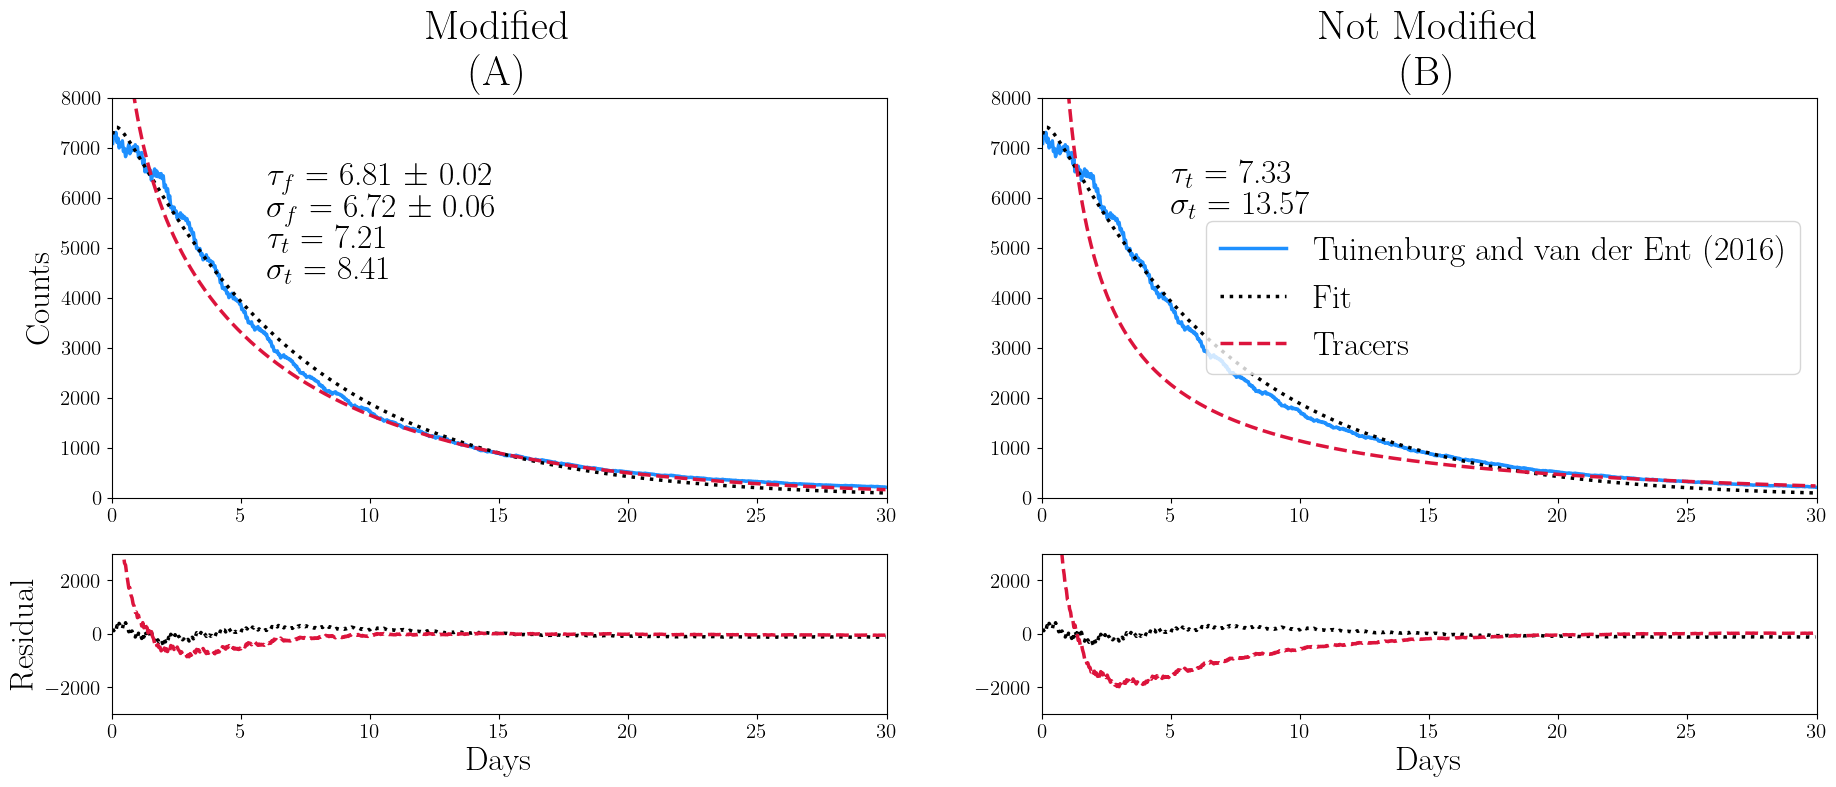

In [14]:
N = np.sum(evap_global)

popt, pcov = curve_fit(gamma_dist, time, evap_global/N,p0 = [10,110])
perr = np.sqrt(np.diag(pcov))
uncert_mean, unc_mom2 = perr
fitted_mean, fitted_mom2 = popt
std_fit = np.sqrt(fitted_mom2-fitted_mean**2)
err_std_fit = np.sqrt(
    (unc_mom2) ** 2 / (4 * (fitted_mom2 - fitted_mean**2)) +
    (fitted_mean**2 * uncert_mean**2) / (fitted_mom2 - fitted_mean**2)
)

fig,axs = plt.subplots(2,2,figsize = (22,8),height_ratios=[2.5, 1])
ax = axs[0,0]
ax.plot(time, evap_global, label = "Ent and Tuinenburg (2016)",color = "dodgerblue",linestyle = "solid",linewidth = 2.5)
ax.plot(time,N *gamma_dist(time,fitted_mean,fitted_mom2),label = "Fit",color = "black",linestyle = "dotted",linewidth = 2.5)
ax.plot(time, N * gamma_dist(time,global_mean_mod,global_mom2_mod),label = "Tracers",color = "crimson",linestyle = "dashed",linewidth = 2.5)


ax.text(6,6500-250, r"$\tau_{f}$" + f" = {round(fitted_mean,2)}" + r" $\pm$ " + f"{round(uncert_mean,2)}",fontsize = 24)
ax.text(6,6000-290-100, r"$\sigma_{f}$" + f" = {round(std_fit,2)}" + r" $\pm$ " + f"{round(err_std_fit,2)}",fontsize = 24)
ax.text(6,5500-300-200, r"$\tau_{t}$" + f" = {round(global_mean_mod,2)}",fontsize = 24)
ax.text(6,5000-325-300, r"$\sigma_{t}$" + f" = {round(std_global_mod,2)}",fontsize = 24)
ax.set_xlim(0,30)

ax.set_ylabel("Counts",fontsize = 24)
ax.set_ylim(0,8000)
ax.set_title("Modified \n (A)",pad = 10,fontsize = 30)

ax = axs[1,0]
ax.plot(time,N *gamma_dist(time,fitted_mean,fitted_mom2)-evap_global,label = "Fit",color = "black",linestyle = "dotted",linewidth = 2.5)
ax.plot(time, N * gamma_dist(time,global_mean_mod,global_mom2_mod)-evap_global,label = "Tracers",color = "crimson",linestyle = "dashed",linewidth = 2.5)
ax.set_ylim(-3000,3000)
ax.set_xlim(0,30)
ax.set_xlabel("Days",fontsize = 24)
ax.set_ylabel("Residual",fontsize = 24)

ax = axs[0,1]
ax.plot(time, evap_global, label = "Tuinenburg and van der Ent (2016)",color = "dodgerblue",linestyle = "solid",linewidth = 2.5)
ax.plot(time,N *gamma_dist(time,fitted_mean,fitted_mom2),label = "Fit",color = "black",linestyle = "dotted",linewidth = 2.5)
ax.plot(time, N * gamma_dist(time,global_mean,global_mom2),label = "Tracers",color = "crimson",linestyle = "dashed",linewidth = 2.5)


ax.text(5,6500-200, r"$\tau_{t}$" + f" = {round(global_mean,2)}",fontsize = 24)
ax.text(5,6000-325, r"$\sigma_{t}$" + f" = {round(std_global,2)}",fontsize = 24)
ax.set_xlim(0,30)
ax.legend(loc = "center right",fontsize = 24)

ax.set_ylim(0,8000)
ax.set_title("Not Modified \n (B)",pad = 10,fontsize = 30)

ax = axs[1,1]
ax.plot(time,N *gamma_dist(time,fitted_mean,fitted_mom2)-evap_global,label = "Fit",color = "black",linestyle = "dotted",linewidth = 2.5)
ax.plot(time, N * gamma_dist(time,global_mean,global_mom2)-evap_global,label = "Model",color = "crimson",linestyle = "dashed",linewidth = 2.5)
ax.set_ylim(-3000,3000)
ax.set_xlim(0,30)
ax.set_xlabel("Days",fontsize = 24)


plt.savefig(f"{path_cur}/comp_dist_rudd.png",dpi = 250,bbox_inches = "tight")

In [ ]:

data_2c = xr.open_dataset("./data_rudd/VT2017_Fig2c.nc")
data_2d = xr.open_dataset("./data_rudd/VT2017_Fig2d.nc")
data_2e = xr.open_dataset("./data_rudd/VT2017_Fig2e.nc")

precip_age_ = data_2c.precipitation_residence_time.values/(24*60**2*1e9)
evap_age_ = data_2d.evaporation_residence_time.values/(24*60**2*1e9)
age_ = data_2e["atmospheric age"].values/(24*60**2*1e9)
latc = data_2c.lat.values
lonc = data_2c.lon.values
latd = data_2d.lat.values
lond = data_2d.lon.values
late = data_2e.lat.values
lone = data_2e.lon.values

center_lon = 0
center_idx = np.argmin(np.abs(lone - center_lon))  # should be 0 in this case
roll_amount = 0
print(roll_amount)
# Roll the longitudes
lon_rolled = np.roll(lone, shift=roll_amount)
age = np.roll(age_, shift=roll_amount)
evap_age = np.roll(evap_age_, shift=roll_amount)
precip_age2 = np.roll(precip_age_, shift=roll_amount)

In [ ]:
areae = get_area2(data_2e)
aread = get_area2(data_2d)
areac = get_area2(data_2c)

mean_precip_age2 = dps.area_w_avg(areac,precip_age2.astype(np.float64))
mean_evap_age = dps.area_w_avg(areac,evap_age.astype(np.float64))
mean_age = dps.area_w_avg(areac,age.astype(np.float64))

mean_precipage = dps.area_w_avg(area,precip_age/(24*60**2))
mean_vert = dps.area_w_avg(area,v_age_time.values)

print(mean_precip_age2,mean_evap_age,mean_age,mean_vert,mean_precipage)

In [ ]:

fig, ax = plt.subplots(nrows=2, ncols=2,figsize = (22,15),constrained_layout=True)


ax_age_vert_an = ax[0,0]
dps.plot_2d(precip_age2.astype(np.float64),latc,lone,ax_age_vert_an,"YlGnBu",level_space=np.linspace(0,20,21),land_bool=False,land_mask=land_mask,extend="max")

ax_age_vert_an.set_title("Residence Time of Precipitation \n (A)",fontsize = 30,pad = 20)



ax_age_vert_asym = ax[0,1]
dps.plot_2d(age.astype(np.float64),late,lone,ax_age_vert_asym,"YlGnBu",level_space=np.linspace(0,20,21),land_bool=False,land_mask=land_mask,extend="max")
ax_age_vert_asym.set_title("Age of Atmospheric Water \n (B)",fontsize = 30,pad = 20)

ax_age_vert_asym = ax[1,1]
dps.plot_2d(v_age_time,lat,lon,ax_age_vert_asym,"YlGnBu",level_space=np.linspace(0,20,21),land_bool= False,land_mask=land_mask,extend="max")
ax_age_vert_asym.set_title("$\\overline{\\{\\Lambda\\}/W}$ \n (D)",fontsize = 30,pad = 20)

ax_age_vert_asym = ax[1,0]
dps.plot_2d(precip_age/(24*60**2),lat,lon,ax_age_vert_asym,"YlGnBu",level_space=np.linspace(0,20,21),land_bool=False,land_mask=land_mask,extend="max")
ax_age_vert_asym.set_title("$\\overline{\\nu}$ \n (C)",fontsize = 30,pad = 20)

for i in range(2):
    for j in range(2):
        axi = ax[i,j]
        axi.contour(lon, lat, land_mask,
                colors="black",levels = 1,linewidths=0.5)
        axi.set_ylim(-79,79)


fig = plt.gcf()
fig.canvas.draw() 
fig.savefig(f"{path_cur}/sampleRuudd.png",dpi = 250,bbox_inches = "tight")